In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.preprocessing
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_excel('Pakistan_Studies_9th.xlsx')

In [3]:
df.head()

,Year,Topic_id,Topic,Appeared,Chapter_Name
0,2025,C1-1,Meaning Of Ideology,0,Ideological Basis Of Pakistan
1,2025,C1-2,Sources of Ideology,0,Ideological Basis Of Pakistan
2,2025,C1-3,Need and Significance of Ideology,0,Ideological Basis Of Pakistan
3,2025,C1-4,The foundation and Components of ideology of P...,1,Ideological Basis Of Pakistan
4,2025,C1-5,Two Nation Theory,1,Ideological Basis Of Pakistan


In [4]:
df['Chapter_Name'].unique()

array(['Ideological Basis Of Pakistan', 'Making of Pakistan',
       'Land Of Pakistan', 'History Of Pakistan'], dtype=object)

In [5]:
df.isnull().sum()

Year            0
Topic_id        0
Topic           0
Appeared        0
Chapter_Name    0
dtype: int64

In [6]:
df=df.sort_values(['Topic','Year']).reset_index(drop=True)
df.head()

,Year,Topic_id,Topic,Appeared,Chapter_Name
0,2016,C4-5,Accession of Tribal Areas,0,History Of Pakistan
1,2017,C4-5,Accession of Tribal Areas,0,History Of Pakistan
2,2018,C4-5,Accession of Tribal Areas,0,History Of Pakistan
3,2019,C4-5,Accession of Tribal Areas,0,History Of Pakistan
4,2022,C4-5,Accession of Tribal Areas,0,History Of Pakistan


In [7]:
chapter_weight_map = {
    'Ideological Basis Of Pakistan': 0.114,
    'Making of Pakistan':            0.250,
    'Land Of Pakistan':              0.295,
    'History Of Pakistan':           0.341
}
df['chapter_weight'] = df['Chapter_Name'].map(chapter_weight_map)

In [8]:
gaps = []
last_year_since_appeared = {}
for _, row in df.iterrows():
    topic = row['Topic']
    year = int(row['Year'])
    appeared = row['Appeared']
    if topic not in last_year_since_appeared:
        gaps.append(-1)
    else:
        gaps.append(year - last_year_since_appeared[topic])
    if appeared == 1:
        last_year_since_appeared[topic] = year
df['Gaps'] = gaps

In [9]:
years_in_data = df['Year'].unique()

frequency = []

for _, row in df.iterrows():
    topic = row['Topic']
    year = row['Year']
    
    # Pichle 5 available years nikalo (current year se pehle)
    prev_years = [y for y in years_in_data if y < year]
    last_5_years = prev_years[-5:]
    
    # Us topic ki un years mein appeared values nikalo
    topic_data = df[df['Topic'] == topic]
    count = topic_data[topic_data['Year'].isin(last_5_years)]['Appeared'].sum()
    
    frequency.append(int(count))

df['Frequency_Last_5'] = frequency

In [10]:
df['Appeared_last_year'] = df.groupby('Topic')['Appeared'].shift(1).fillna(0).astype(int)

In [11]:
df['rolling_3'] = (df.groupby('Topic')['Appeared']
                   .transform(lambda x: x.shift(1).rolling(3).sum()))

df['rolling_3'] = df['rolling_3'].fillna(0)

In [12]:
df.isnull().sum()

Year                  0
Topic_id              0
Topic                 0
Appeared              0
Chapter_Name          0
chapter_weight        0
Gaps                  0
Frequency_Last_5      0
Appeared_last_year    0
rolling_3             0
dtype: int64

In [13]:
df_model=df.copy()

## Train Test Split
Here we'll experiment to check how well our model understands pattern that's why we train data on ```2024,2023,2022,2019,2018,2017,2016``` and test on the paper of ```2025```

In [14]:
train = df_model[df_model['Year'] < 2025]
test  = df_model[df_model['Year'] == 2025]

features = ['Gaps', 'Frequency_Last_5','Appeared_last_year','rolling_3','chapter_weight']
targets = 'Appeared'

X_train = train[features]
y_train = train[targets]

X_test = test[features]
y_test = test[targets]

## Baseline Model
  ### ***. LogisticRegression***

In [15]:
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression(class_weight='balanced',random_state=42)
lr_model.fit(X_train,y_train)
lr_predict=lr_model.predict(X_test)

### Accuracy , Precision , Recall

In [16]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
accuracy_lr=accuracy_score(y_test,lr_predict)
precision_lr=precision_score(y_test,lr_predict)
recall_lr=recall_score(y_test,lr_predict)
print(f"Accuracy:  {accuracy_lr * 100:.2f}%")
print(f'Precision:{precision_lr*100:.2f}%')
print(f'Recall:{recall_lr*100:.2f}%')

Accuracy:  63.08%
Precision:48.65%
Recall:78.26%


In [17]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print(f"Dummy Accuracy: {accuracy_score(y_test, dummy.predict(X_test)):.4f}")

Dummy Accuracy: 0.6462


In [18]:
from sklearn.metrics import classification_report

y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.4, 0.3, 0.25]:
    y_pred_thresh = (y_prob_lr >= threshold).astype(int)
    print(f'Accuracy:{accuracy_score(y_test,y_pred_thresh)*100:.2f}%')
    print(f"\nThreshold={threshold}")
    print(classification_report(y_test, y_pred_thresh))

Accuracy:63.08%

Threshold=0.5
              precision    recall  f1-score   support

           0       0.82      0.55      0.66        42
           1       0.49      0.78      0.60        23

    accuracy                           0.63        65
   macro avg       0.65      0.67      0.63        65
weighted avg       0.70      0.63      0.64        65

Accuracy:56.92%

Threshold=0.4
              precision    recall  f1-score   support

           0       1.00      0.33      0.50        42
           1       0.45      1.00      0.62        23

    accuracy                           0.57        65
   macro avg       0.73      0.67      0.56        65
weighted avg       0.81      0.57      0.54        65

Accuracy:35.38%

Threshold=0.3
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        42
           1       0.35      1.00      0.52        23

    accuracy                           0.35        65
   macro avg       0.18      0.50  

c:\Users\aliah\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aliah\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aliah\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight='balanced',n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred=rf_model.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
rf_accuracy=accuracy_score(y_test,rf_pred)
rf_precision=precision_score(y_test,rf_pred)
rf_recall=recall_score(y_test,rf_pred)
print(f'Accuarcy:{rf_accuracy*100:.2f}%')
print(f'Precision:{rf_precision*100:.2f}%')
print(f'Recall:{rf_recall*100:.2f}%')

Accuarcy:64.62%
Precision:50.00%
Recall:56.52%


In [21]:
from xgboost import XGBClassifier
xg_model = XGBClassifier(scale_pos_weight=3, random_state=42)
xg_model.fit(X_train, y_train)
xg_pred=xg_model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
xg_accuracy=accuracy_score(y_test,xg_pred)
xg_precision=precision_score(y_test,xg_pred)
xg_recall=recall_score(y_test,xg_pred)
print(f'Accuracy:{xg_accuracy*100:.2f}%')
print(f'Precison:{xg_precision*100:.2f}%')
print(f'Recall:{xg_recall*100:.2f}%')

Accuracy:52.31%
Precison:35.71%
Recall:43.48%


Pakistan Studies mein koi bhi ML model DummyClassifier baseline ko beat nahi kar saka, jo indicate karta hai ke board ka topic selection pattern sufficiently consistent nahi hai ML-based prediction ke liye. Isliye CS ki tarah frequency-gap ranking approach use ki gayi

In [23]:
total_years = df['Year'].nunique()

freq = (df.groupby('Topic')['Appeared'].sum() / total_years).rename('Appearance_Rate')

last_seen = (df[df['Appeared'] == 1]
             .groupby('Topic')['Year'].max()
             .rename('Last_Seen'))

max_year = df['Year'].max()

ranking = pd.DataFrame(freq).join(last_seen)
ranking['Gap'] = max_year - ranking['Last_Seen']
ranking['Gap'] = ranking['Gap'].fillna(999)

topic_id_map = df[['Topic','Topic_id']].drop_duplicates().set_index('Topic')['Topic_id']
ranking = ranking.join(topic_id_map)

ranking['Score'] = ranking['Appearance_Rate'] - (ranking['Gap'] / ranking['Gap'].max()) * 0.3
ranking = ranking.sort_values('Score', ascending=False).reset_index()
ranking['Rank'] = ranking.index + 1
ranking.head(15)

,Topic,Appearance_Rate,Last_Seen,Gap,Topic_id,Score,Rank
0,Muslim League and Two Nation Theory,0.875,2025.0,0.0,C1-6,0.8750,1
1,Location of Pakistan,0.875,2025.0,0.0,C3-1,0.8750,2
2,Two Nation Theory,0.750,2025.0,0.0,C1-5,0.7500,3
3,The Third June Plan(1947),0.750,2025.0,0.0,C2-11,0.7500,4
4,Constitution of 1956,0.625,2025.0,0.0,C4-8,0.6250,5
5,Environmental Problems of Pakistan,0.625,2025.0,0.0,C3-16,0.6250,6
6,Climatic Zones of Pakistan,0.625,2025.0,0.0,C3-10,0.6250,7
7,Objectives Resolution,0.625,2025.0,0.0,C4-6,0.6250,8
8,Meaning Of Ideology,0.625,2024.0,1.0,C1-1,0.6247,9
9,General Elections(1945-46),0.500,2025.0,0.0,C2-7,0.5000,10


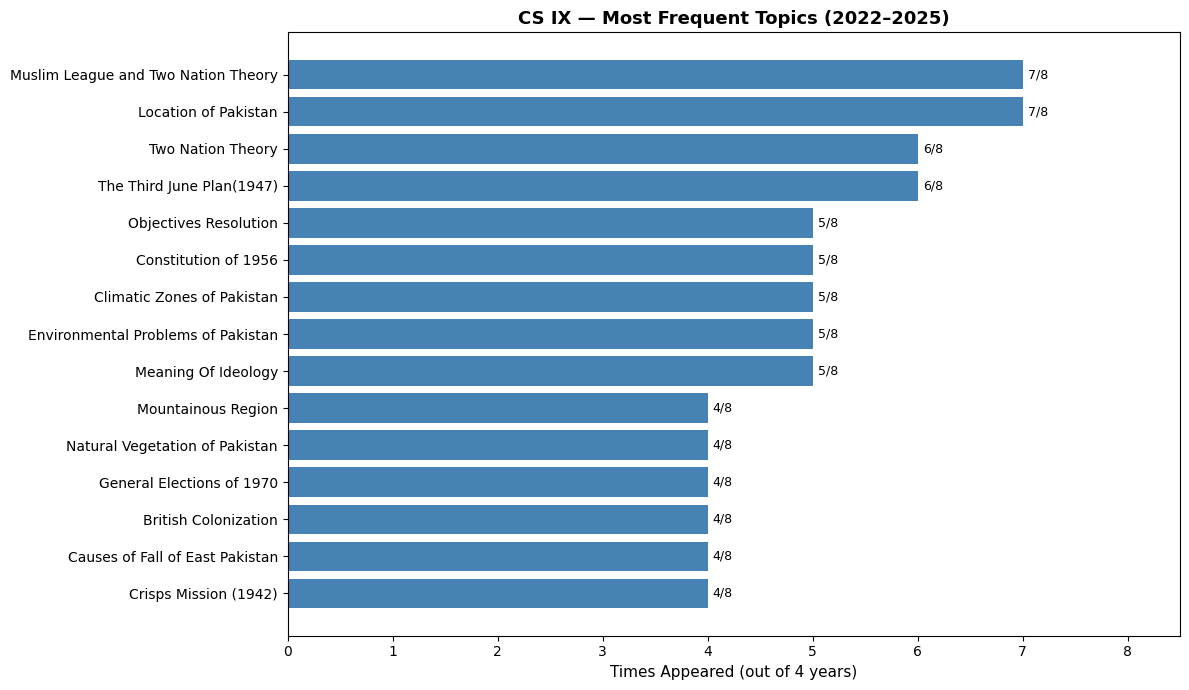

In [24]:
total_appearances = df.groupby('Topic')['Appeared'].sum().sort_values(ascending=False)
top15 = total_appearances.head(15)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15.index[::-1], top15.values[::-1], color='steelblue')

for bar, val in zip(bars, top15.values[::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val}/{total_years}', va='center', fontsize=9)

ax.set_xlabel('Times Appeared (out of 4 years)', fontsize=11)
ax.set_title('CS IX — Most Frequent Topics (2022–2025)', fontsize=13, fontweight='bold')
ax.set_xlim(0, total_years + 0.5)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('cs_graph1_frequency.png', dpi=150)
plt.show()

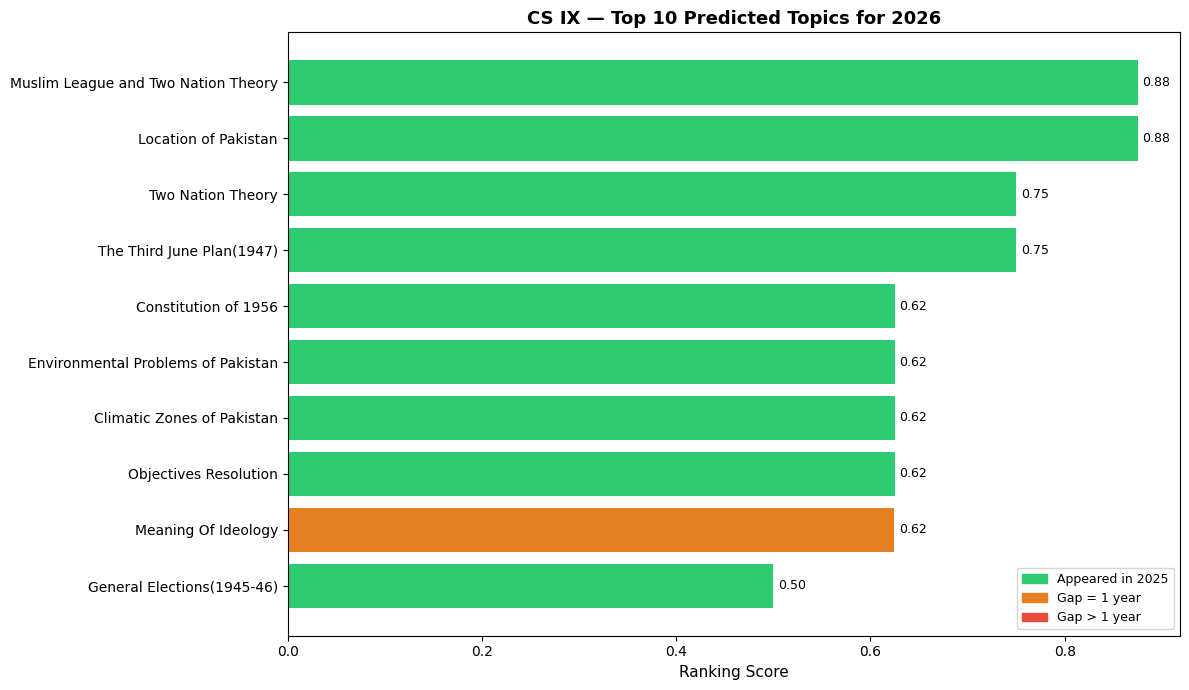

In [25]:
from matplotlib.patches import Patch

top10 = ranking.head(10)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#2ecc71' if g == 0 else '#e67e22' if g == 1 else '#e74c3c'
          for g in top10['Gap']]
bars = ax.barh(top10['Topic'][::-1], top10['Score'][::-1], color=colors[::-1])

for bar, val in zip(bars, top10['Score'][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

ax.set_xlabel('Ranking Score', fontsize=11)
ax.set_title('CS IX — Top 10 Predicted Topics for 2026', fontsize=13, fontweight='bold')

legend = [Patch(color='#2ecc71', label='Appeared in 2025'),
          Patch(color='#e67e22', label='Gap = 1 year'),
          Patch(color='#e74c3c', label='Gap > 1 year')]
ax.legend(handles=legend, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('cs_graph2_predictions.png', dpi=150)
plt.show()

In [33]:
# Chapter map karo df se
topic_chapter_map = df[['Topic', 'Chapter_Name']].drop_duplicates().set_index('Topic')['Chapter_Name'].to_dict()

appeared_years_list = []
for _, row in ranking.head(25).iterrows():
    topic = row['Topic']
    years = df[
        (df['Topic'] == topic) &
        (df['Appeared'] == 1)
    ]['Year'].tolist()
    appeared_years_list.append(', '.join(map(str, sorted(years))))

final_ranking = ranking.head(25).copy()
final_ranking['Chapter_Name'] = final_ranking['Topic'].map(topic_chapter_map)
final_ranking['Years_Appeared'] = appeared_years_list
final_ranking['Total_Appearances'] = final_ranking['Years_Appeared'].apply(
    lambda x: len(x.split(', ')) if x else 0
)
final_ranking['Category'] = final_ranking['Score'].apply(
    lambda x: 'A - Must Prepare' if x >= 0.7 else 'B - Should Prepare'
)

final_ranking = final_ranking[['Topic_id', 'Topic', 'Chapter_Name', 'Score', 'Category', 'Years_Appeared', 'Total_Appearances']]\
    .rename(columns={'Score': 'Probability'})

final_ranking.to_excel('PS_9th_Predictions_2026.xlsx', index=False)
print(final_ranking)

   Topic_id                                              Topic  \
0      C1-6                Muslim League and Two Nation Theory   
1      C3-1                               Location of Pakistan   
2      C1-5                                  Two Nation Theory   
3     C2-11                          The Third June Plan(1947)   
4      C4-8                               Constitution of 1956   
5     C3-16                 Environmental Problems of Pakistan   
6     C3-10                         Climatic Zones of Pakistan   
7      C4-6                              Objectives Resolution   
8      C1-1                                Meaning Of Ideology   
9      C2-7                         General Elections(1945-46)   
10    C3-13                     Natural Vegetation of Pakistan   
11     C3-4                                 Mountainous Region   
12    C4-24                    Causes of Fall of East Pakistan   
13     C2-3                              Crisps Mission (1942)   
14    C4-2

In [ ]:
ranking[['Rank','Topic_id','Topic','Appearance_Rate','Gap','Score']].to_excel(
    'cs_ranking_2026.xlsx', index=False)
print("Done — cs_ranking_2026.xlsx saved")

Done — cs_ranking_2026.xlsx saved
